# Week 9 · Hyperparameter Tuning
## Grid Search · Random Search · Bayesian Optimization (Optuna)

**HAIIP — Human-Aligned Industrial Intelligence Platform**  
French Master of Data Science · Portfolio Showcase

---

### Why Hyperparameter Optimization Matters

Models like Random Forest or XGBoost have **dozens of hyperparameters**. Their effect on performance is:
- Non-linear (doubling `n_estimators` doesn't double accuracy)
- Interdependent (`max_depth` interacts with `min_samples_leaf`)
- Problem-specific (optimal for one dataset ≠ optimal for another)

**Objective function:**
$$\lambda^* = \arg\max_{\lambda \in \Lambda} \mathbb{E}_{(\mathbf{X}_{\text{train}}, \mathbf{X}_{\text{val}}) \sim \mathcal{D}} \left[ \mathcal{M}(A(\lambda, \mathbf{X}_{\text{train}}), \mathbf{X}_{\text{val}}) \right]$$

where $A(\lambda, \mathbf{X}_{\text{train}})$ is the algorithm trained with hyperparameters $\lambda$ and $\mathcal{M}$ is the evaluation metric.

This is an **expensive black-box optimization**: each evaluation requires training a model (minutes to hours).

### Methods Compared
| Method | Strategy | Evaluations | Best for |
|--------|----------|-------------|----------|
| Grid Search | Exhaustive | $O(\prod k_i)$ | ≤ 3 hyperparameters |
| Random Search | Stochastic | Fixed $n$ | Medium-dimensional |
| Bayesian (TPE) | Surrogate model | Fixed $n$ | High-dimensional, expensive |

In [1]:
# !pip install numpy pandas scikit-learn matplotlib seaborn optuna

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from scipy.stats import randint, uniform

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print(f'Optuna {optuna.__version__} available.')
except ImportError:
    OPTUNA_AVAILABLE = False
    print('Optuna not installed: pip install optuna')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
print('Libraries loaded.')

Optuna 4.7.0 available.
Libraries loaded.


In [3]:
# Industrial bearing fault dataset (imbalanced, multi-class)
X, y = make_classification(
    n_samples=1500, n_features=12, n_informative=7, n_redundant=3,
    n_classes=4, n_clusters_per_class=1, weights=[0.6, 0.15, 0.15, 0.10],
    flip_y=0.02, random_state=42
)
scaler = StandardScaler()
X = scaler.fit_transform(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Dataset: {X.shape}, classes: {np.bincount(y)}')

Dataset: (1500, 12), classes: [894 225 227 154]


## 1 · Grid Search

Exhaustively evaluates **every combination** of the specified parameter grid.  
Total evaluations = $\prod_{i} |G_i| \times k_{\text{CV}}$

For a $3 \times 3 \times 4$ grid with 5-fold CV: $36 \times 5 = 180$ fits.

**Guaranteed to find the optimal on the discrete grid**, but exponentially expensive:  
adding one more parameter with 5 values multiplies cost by 5.

In [4]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, None],
    'min_samples_leaf': [1, 2, 5, 10]
}
total_fits = np.prod([len(v) for v in param_grid.values()]) * 5
print(f'Grid Search: {total_fits} total fits ({np.prod([len(v) for v in param_grid.values()])} combinations × 5 CV)')

t0 = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0
)
grid_search.fit(X, y)
t_grid = time.time() - t0

print(f'\nBest params : {grid_search.best_params_}')
print(f'Best F1-macro: {grid_search.best_score_:.4f}')
print(f'Time elapsed: {t_grid:.1f}s')

Grid Search: 180 total fits (36 combinations × 5 CV)



Best params : {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 50}
Best F1-macro: 0.8402
Time elapsed: 51.6s


## 2 · Random Search

Samples hyperparameter combinations **randomly** from continuous/discrete distributions.

**Key insight** (Bergstra & Bengio, 2012):  
If only a few hyperparameters are important, random search explores them more efficiently than grid search,  
because it doesn't waste evaluations on the unimportant ones.

With $n$ evaluations on a grid of $k$ parameters, grid search tests $n^{1/k}$ values per parameter,  
while random search tests $n$ distinct values per important parameter.

In [5]:
param_dist = {
    'n_estimators':     randint(50, 500),
    'max_depth':        [3, 4, 5, 6, 7, None],
    'min_samples_leaf': randint(1, 20),
    'max_features':     uniform(0.3, 0.7),   # fraction of features
    'min_samples_split': randint(2, 15),
}

t0 = time.time()
random_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    param_dist, n_iter=36, cv=cv, scoring='f1_macro', n_jobs=-1, random_state=42, verbose=0
)
random_search.fit(X, y)
t_random = time.time() - t0

print(f'Random Search: 36 iterations (same budget as grid)')
print(f'Best params : {random_search.best_params_}')
print(f'Best F1-macro: {random_search.best_score_:.4f}')
print(f'Time elapsed: {t_random:.1f}s')

Random Search: 36 iterations (same budget as grid)
Best params : {'max_depth': None, 'max_features': np.float64(0.9210489198034286), 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 150}
Best F1-macro: 0.8406
Time elapsed: 142.8s


## 3 · Bayesian Optimization (Optuna — TPE)

### Mathematical Foundation

Bayesian optimization uses a **surrogate model** $\hat{f}$ to approximate the expensive objective $f(\lambda)$,  
then maximises an **acquisition function** to select the next point to evaluate.

**Optuna's TPE (Tree-structured Parzen Estimator)** models:  
$$p(\lambda \mid y) = \begin{cases} l(\lambda) & \text{if } y < y^* \\ g(\lambda) & \text{if } y \geq y^* \end{cases}$$

where $l(\lambda)$ is the density of **good** configurations and $g(\lambda)$ of **bad** ones.  
$y^*$ is the $\gamma$-quantile of observed scores (typically $\gamma = 0.25$).

**Acquisition**: maximise $\text{EI}(\lambda) \propto \dfrac{l(\lambda)}{g(\lambda)}$  

TPE builds $l$ and $g$ as **kernel density estimates (KDE)** on the observed points,  
enabling sampling from $l$ and evaluating the ratio — no Gaussian Process required → handles discrete/conditional search spaces naturally.

In [6]:
if OPTUNA_AVAILABLE:
    def objective(trial):
        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
            'max_depth':         trial.suggest_int('max_depth', 2, 15),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
            'max_features':      trial.suggest_float('max_features', 0.2, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        }
        model = RandomForestClassifier(
            **params, class_weight='balanced', n_jobs=-1, random_state=42
        )
        scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
        return scores.mean()

    t0 = time.time()
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=36, show_progress_bar=False)
    t_bayes = time.time() - t0

    print(f'Bayesian (TPE): 36 trials')
    print(f'Best params : {study.best_params}')
    print(f'Best F1-macro: {study.best_value:.4f}')
    print(f'Time elapsed: {t_bayes:.1f}s')
else:
    print('Install Optuna: pip install optuna')

Bayesian (TPE): 36 trials
Best params : {'n_estimators': 78, 'max_depth': 13, 'min_samples_leaf': 1, 'max_features': 0.8315816530555719, 'min_samples_split': 9}
Best F1-macro: 0.8498
Time elapsed: 123.9s


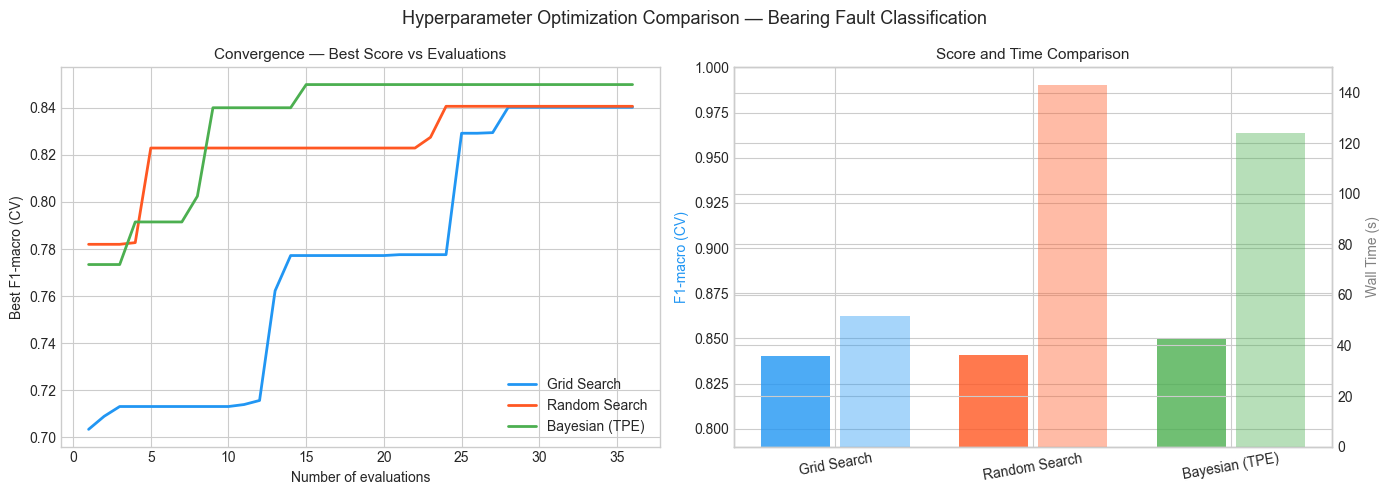

In [7]:
# Extract score histories for convergence plot
grid_scores   = pd.DataFrame(grid_search.cv_results_)['mean_test_score'].sort_values(ascending=False)
random_scores = pd.DataFrame(random_search.cv_results_)['mean_test_score'].sort_values(ascending=False)

# Cumulative best
def cummax(arr):
    return np.maximum.accumulate(arr)

# For grid/random: use order in which configs were evaluated
grid_best   = cummax(pd.DataFrame(grid_search.cv_results_)['mean_test_score'].values)
random_best = cummax(pd.DataFrame(random_search.cv_results_)['mean_test_score'].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence
axes[0].plot(range(1, len(grid_best)+1),   grid_best,   color=PALETTE[0], linewidth=2, label='Grid Search')
axes[0].plot(range(1, len(random_best)+1), random_best, color=PALETTE[1], linewidth=2, label='Random Search')
if OPTUNA_AVAILABLE:
    optuna_vals = [t.value for t in study.trials]
    optuna_best = cummax(optuna_vals)
    axes[0].plot(range(1, len(optuna_best)+1), optuna_best, color=PALETTE[2], linewidth=2, label='Bayesian (TPE)')
axes[0].set_xlabel('Number of evaluations')
axes[0].set_ylabel('Best F1-macro (CV)')
axes[0].set_title('Convergence — Best Score vs Evaluations', fontsize=11)
axes[0].legend()

# Bar comparison
methods = ['Grid Search', 'Random Search']
scores  = [grid_search.best_score_, random_search.best_score_]
times   = [t_grid, t_random]
colors  = PALETTE[:2]
if OPTUNA_AVAILABLE:
    methods.append('Bayesian (TPE)')
    scores.append(study.best_value)
    times.append(t_bayes)
    colors.append(PALETTE[2])

x = np.arange(len(methods))
axes[1].bar(x - 0.2, scores, width=0.35, color=colors, alpha=0.8, label='F1-macro')
ax_t = axes[1].twinx()
ax_t.bar(x + 0.2, times, width=0.35, color=colors, alpha=0.4, label='Time (s)')
axes[1].set_xticks(x); axes[1].set_xticklabels(methods, rotation=10)
axes[1].set_ylabel('F1-macro (CV)', color=PALETTE[0])
ax_t.set_ylabel('Wall Time (s)', color='gray')
axes[1].set_title('Score and Time Comparison', fontsize=11)
axes[1].set_ylim(max(0, min(scores) - 0.05), 1.0)

plt.suptitle('Hyperparameter Optimization Comparison — Bearing Fault Classification', fontsize=13)
plt.tight_layout()
plt.savefig('plots/09_hpo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

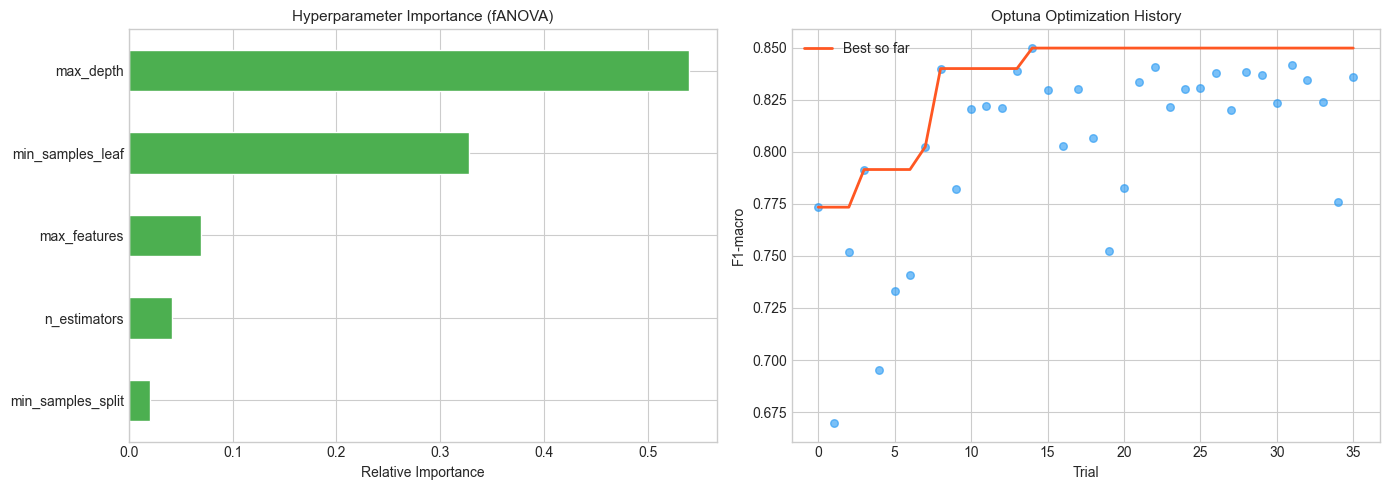

In [8]:
if OPTUNA_AVAILABLE:
    try:
        # Hyperparameter importance (fANOVA)
        importance = optuna.importance.get_param_importances(study)
        imp_df = pd.Series(importance).sort_values(ascending=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Importance
        imp_df.plot(kind='barh', ax=ax1, color=PALETTE[2], edgecolor='white')
        ax1.set_title('Hyperparameter Importance (fANOVA)', fontsize=11)
        ax1.set_xlabel('Relative Importance')

        # Optimization history
        trial_nums = [t.number for t in study.trials]
        trial_vals = [t.value for t in study.trials]
        ax2.scatter(trial_nums, trial_vals, c=PALETTE[0], alpha=0.6, s=30)
        ax2.plot(trial_nums, cummax(trial_vals), color=PALETTE[1], linewidth=2, label='Best so far')
        ax2.set_xlabel('Trial'); ax2.set_ylabel('F1-macro')
        ax2.set_title('Optuna Optimization History', fontsize=11)
        ax2.legend()

        plt.tight_layout()
        plt.savefig('plots/09_optuna_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f'Importance plot requires optuna[visualization]: {e}')

## 4 · Discussion & Recommendations

### Why Bayesian > Grid/Random (in general)

With the same evaluation budget (36 trials):  
- Grid Search: wastes budget on poor-performing regions of the space  
- Random Search: no memory — samples the same poor regions repeatedly  
- Bayesian (TPE): **learns from history**, concentrates on promising regions  

This advantage grows with:
- Higher dimensionality of $\Lambda$
- Smaller evaluation budget relative to $|\Lambda|$
- More expensive objective function (deep learning training)

### When Grid Search is Appropriate
- ≤ 2–3 hyperparameters with clear discrete candidates
- Reproducibility required (identical results guaranteed)
- Regulatory audit context (EU AI Act traceable documentation)

### HAIIP Implementation
In production, HAIIP uses `ExperimentTracker` (`haiip/core/experiment.py`)  
which wraps Optuna studies and logs all trials to the database with timestamps and scores,  
satisfying **EU AI Act Article 12** (record keeping) and enabling A/B testing between model versions.

→ **Week 10**: Feature engineering — raw sensors → informative features.